# Robust MRAC Python Simulation
 This notebook implements a Robust Model Reference Adaptive Control (MRAC) system for a second-order plant with uncertainties. It demonstrates both nominal and adaptive control responses, including mathematical settings and simulation plots.

In [36]:
# Import Required Libraries
import controlsim as csm
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 10
dt = 0.005

In [37]:
# Plant Definition
A = np.matrix([[0, 1], [-1, -2]], dtype=float)
B = np.matrix([[0], [0.5]], dtype=float)
C = np.matrix([[1, 0]], dtype=float)
D = np.matrix([[0]], dtype=float)
sys = ctrl.ss(A, B, C, D)
plant = csm.ProcessDefinition(sys, 0.0, dt=dt)

### Plant Mathematical Formulation
The plant is represented as:
$$
\dot{x} = Ax + Bu
$$
$$
y = Cx + Du
$$
where:
- $A = \begin{bmatrix} 0 & 1 \\ -1 & -2 \end{bmatrix}$
- $B = \begin{bmatrix} 0 \\ 0.5 \end{bmatrix}$
- $C = \begin{bmatrix} 1 & 0 \end{bmatrix}$
- $D = 0$

In [38]:
# Reference Model Definition
Am = np.matrix([[0, 1], [-1, -3]], dtype=float)
Bm = np.matrix([[0], [1]], dtype=float)
Cm = np.matrix([[1, 1]], dtype=float)
Dm = np.matrix([[0]], dtype=float)

K_x = -ctrl.place(A, B, np.linalg.eigvals(Am))
K_r = -np.linalg.inv(Cm @ np.linalg.inv(Am) @ B)
K_x = np.matrix(K_x).reshape(1, 2)
K_r = np.matrix(K_r).reshape(1, 1)
sysm = ctrl.ss(Am, Bm, Cm, Dm)
plant_ref = csm.ProcessDefinition(sysm, 0.0, dt=dt)

### Reference Model Mathematical Formulation
The reference model is:
$$
\dot{x}_m = A_m x_m + B_m r
$$
$$
y_m = C_m x_m + D_m r
$$
where:
- $A_m = \begin{bmatrix} 0 & 1 \\ -1 & -3 \end{bmatrix}$
- $B_m = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$
- $C_m = \begin{bmatrix} 1 & 1 \end{bmatrix}$
- $D_m = 0$

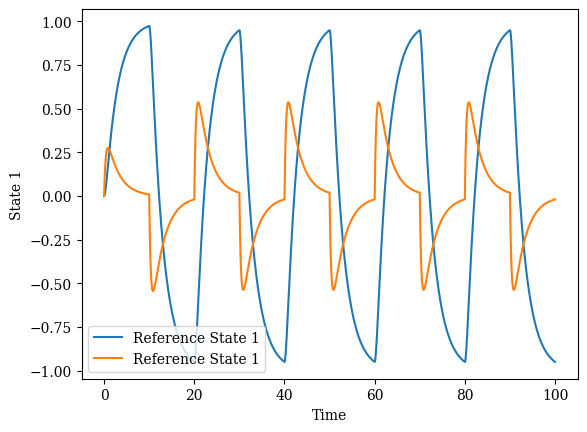

Lyapunov Matrix P:
 [[1.83333333 0.5       ]
 [0.5        0.33333333]]


In [39]:
# Simulation of nominal system
sim_time = 100
t = np.arange(0, sim_time, dt)
plant.reset()
plant_ref.reset()
for i in range(len(t) - 1):
    u = np.sign(np.sin(2 * np.pi * 0.05 * t[i]))
    plant.step(u)
    plant_ref.step(u)

plt.figure()
plt.plot(plant_ref.t, plant_ref.x, label="Reference State 1")
plt.xlabel("Time")
plt.ylabel("State 1")
plt.legend()
plt.show()

P = ctrl.lyap(Am.transpose(), np.eye(2))
print("Lyapunov Matrix P:\n", P)

### Lyapunov Matrix
The Lyapunov matrix $P$ is computed as the solution to:
$$
A_m^T P + P A_m = -Q
$$
where $Q$ is a positive definite matrix (here, $Q = I$).
This ensures stability for the adaptive law.

In [40]:
# Uncertainty Introduction
def get_alpha(x, t):
    alpha = np.zeros(3)
    alpha[0] = np.sin(2 * np.pi * 100 * x[0, 0] * t)
    alpha[1] = np.cos(2 * np.pi * 2 * x[1, 0] * t)
    alpha[2] = 1.0
    return np.matrix(alpha, dtype=float).reshape(3, 1)


def run_sumulation(gamma, sim_time):
    What = np.matrix([0.0, 0.0, 0.0], dtype=float).reshape(3, 1)
    x = np.matrix([0.0, 0.0], dtype=float).reshape(2, 1)
    xm = np.matrix([0.0, 0.0], dtype=float).reshape(2, 1)
    u_t = []
    T_t = []
    alpha_t = []
    X = np.empty((2, 0), dtype=float)
    Xm = np.empty((2, 0), dtype=float)
    t = np.arange(0, sim_time, dt)
    W_hat = np.empty((3, 0), dtype=float)
    plant.reset()
    plant_ref.reset()
    for i in range(len(t) - 1):
        Ref = np.sign(np.sin(2 * np.pi * 0.02 * t[i]))
        u = K_r * Ref + K_x @ x - What.T @ get_alpha(x, t[i])
        x, _, ts = plant.step(u + W @ get_alpha(x, t[i]))
        xm, _, _ = plant_ref.step(Ref)
        x = np.matrix(x).reshape(2, 1)
        xm = np.matrix(xm).reshape(2, 1)
        e = x - xm
        Wgain = gamma * (e.transpose() * P * B)
        What_dot = Wgain[0, 0] * get_alpha(x, t[i])
        What += What_dot * dt
        u_t.append(u.item())
        T_t.append(t[i])
        W_hat = np.append(W_hat, What, axis=1)
        X = np.append(np.asarray(X), x, axis=1)
        Xm = np.append(np.asarray(Xm), xm, axis=1)
        alpha_t.append(get_alpha(x, t[i]))
    return X, Xm, u_t, T_t, W_hat, alpha_t

### Uncertainty and Adaptive Law Details
The plant uncertainty is modeled as:
$$
\Delta(x, t) = W^T \alpha(x, t)
$$
where $W$ is the true parameter vector and $\alpha(x, t)$ is the basis function vector.
The adaptive law updates parameter estimates as:
$$
\dot{\hat{W}} = \gamma \alpha(x, t) e^T P B 
$$
where:
- $\gamma$: adaptation gain
- $e = x - x_m$: tracking error
- $P$: Lyapunov matrix
- $B$: input matrix
- $\alpha(x, t)$: basis functions
<style>
img[alt="image.png"] {
    height: 3.5in;
    width: auto;
}
</style>
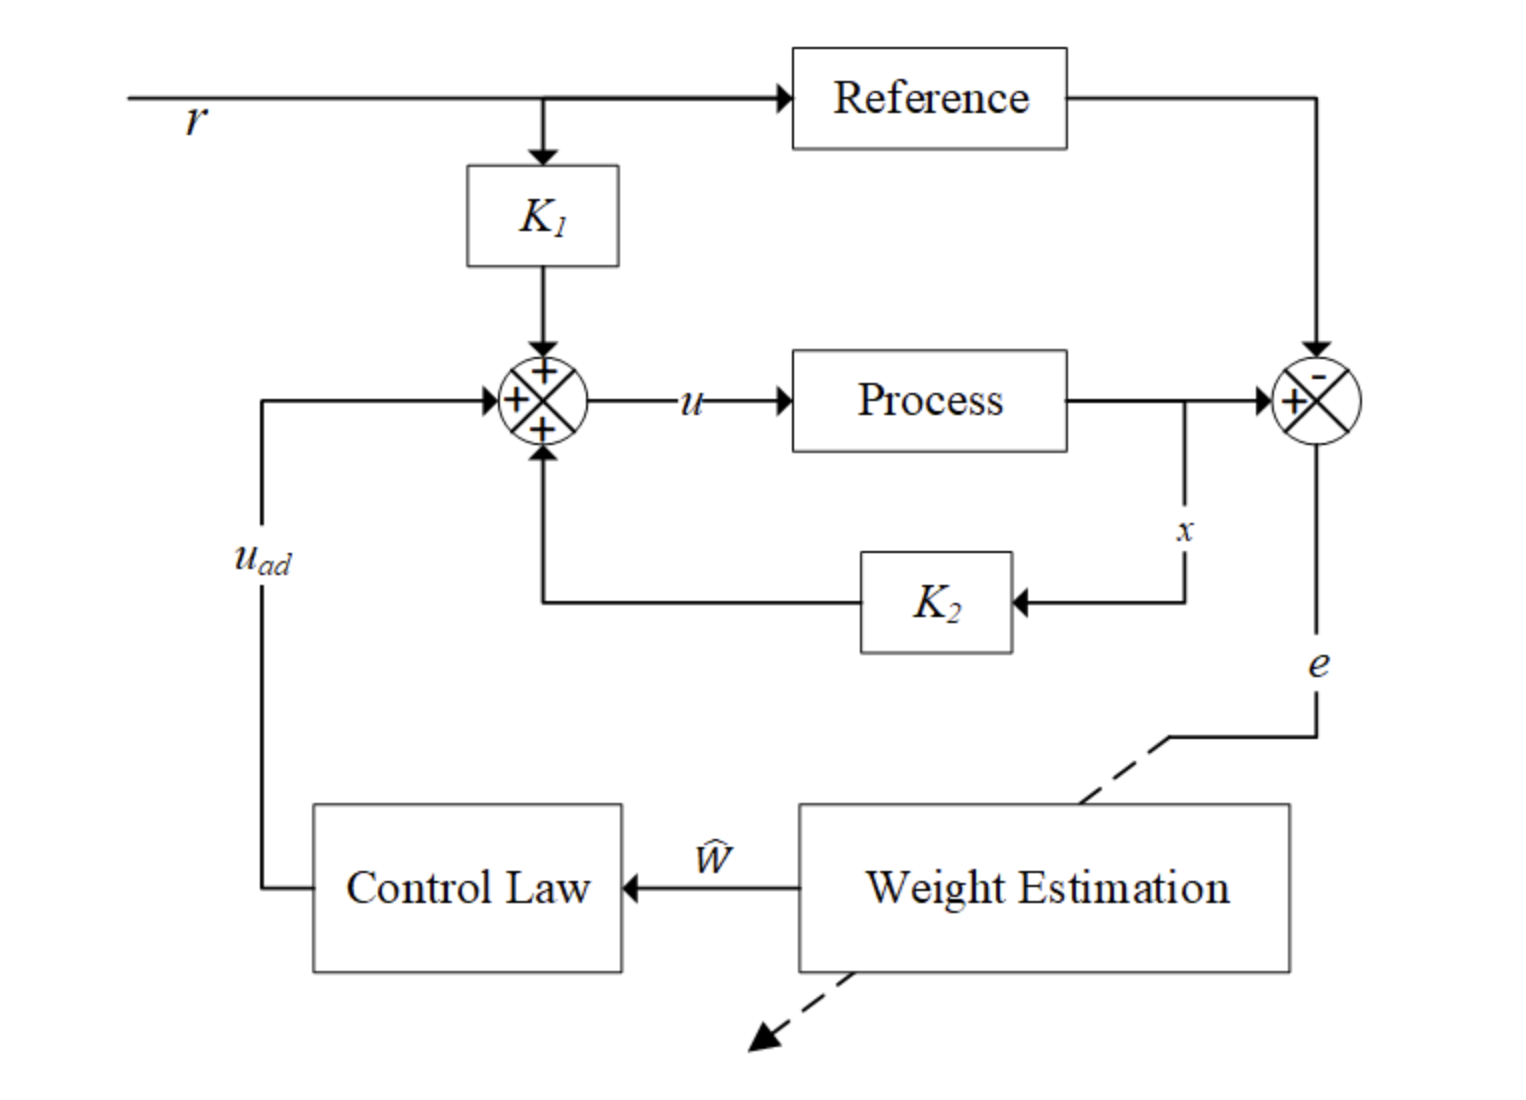

In [41]:
# Response and Plotting
sim_time = 300
W = np.matrix([0.1, 0.2, -0.5], dtype=float).reshape(1, 3)
x, xm, u_t, T_t, W_hat, alpha_t = run_sumulation(
    gamma=0.0, sim_time=sim_time
)  # Adaptive OFF
x_1, xm_1, u_t_1, T_t_1, W_hat_1, alpha_t_1 = run_sumulation(
    gamma=200.0, sim_time=sim_time
)  # Adaptive ON
print("The actual weights are:\n", np.array(W).flatten())
print(
    "Final Weight Estimates with Adaptive Control:\n",
    np.array(W_hat_1[:, -1]).flatten(),
)

The actual weights are:
 [ 0.1  0.2 -0.5]
Final Weight Estimates with Adaptive Control:
 [ 0.09545012  0.20014301 -0.50013745]


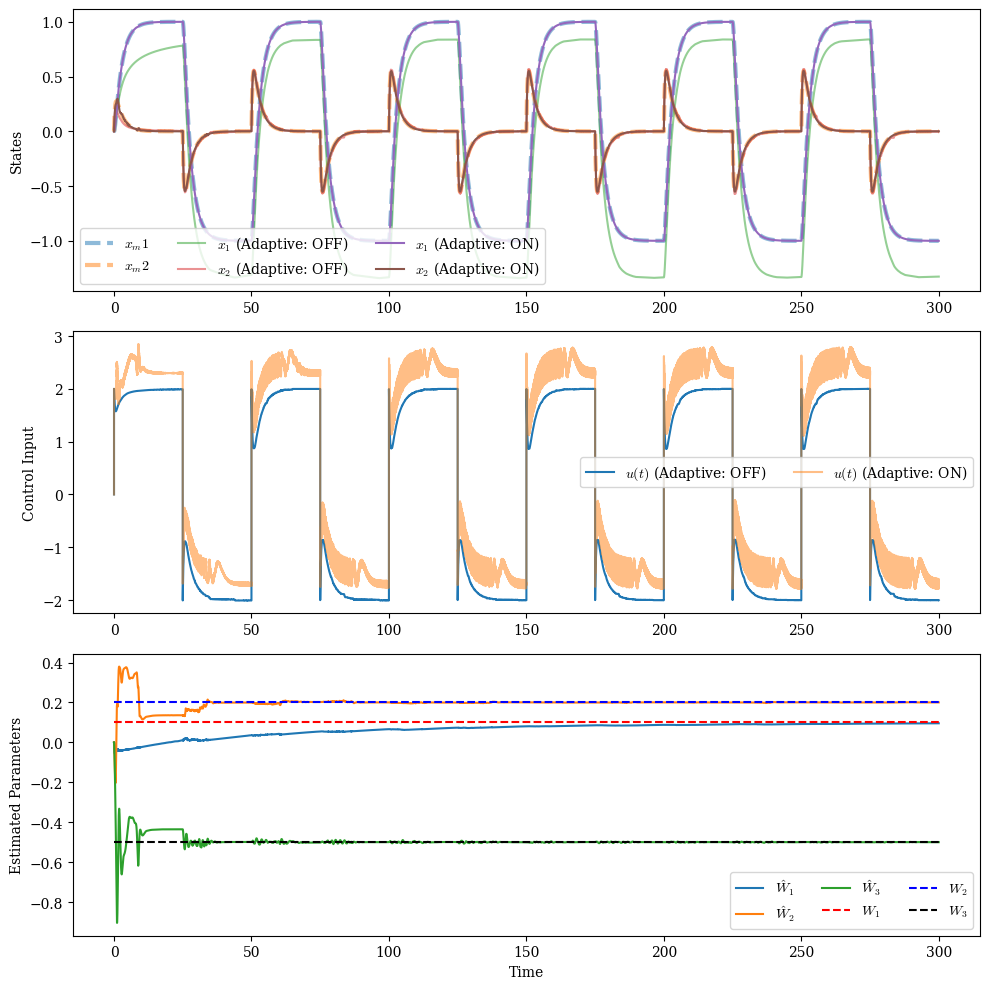

In [42]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))
n = xm.shape[0]

labels_ref = [rf"$x_m{i+1}$" for i in range(n)]
labels_off = [rf"$x_{i+1}$ (Adaptive: OFF)" for i in range(n)]
labels_on = [rf"$x_{i+1}$ (Adaptive: ON)" for i in range(n)]

axs[0].plot(T_t, xm.T, label=labels_ref, linestyle="--", linewidth=3, alpha=0.5)
axs[0].plot(T_t, x.T, label=labels_off, alpha=0.5)
axs[0].plot(T_t_1, x_1.T, label=labels_on)
axs[0].set_ylabel("States")
axs[0].legend(ncol=3)

axs[1].plot(T_t, u_t, label=r"$u(t)$ (Adaptive: OFF)")
axs[1].plot(T_t_1, u_t_1, label=r"$u(t)$ (Adaptive: ON)", alpha=0.5)
axs[1].set_ylabel("Control Input")
axs[1].legend(ncol=3)

axs[2].plot(T_t, np.asarray(W_hat_1[0]).flatten(), label=r"$\hat{W}_1$")
axs[2].plot(T_t, np.asarray(W_hat_1[1]).flatten(), label=r"$\hat{W}_2$")
axs[2].plot(T_t, np.asarray(W_hat_1[2]).flatten(), label=r"$\hat{W}_3$")

axs[2].hlines(W[0, 0], T_t[0], T_t[-1], colors="r", linestyles="dashed", label=r"$W_1$")
axs[2].hlines(W[0, 1], T_t[0], T_t[-1], colors="b", linestyles="dashed", label=r"$W_2$")
axs[2].hlines(W[0, 2], T_t[0], T_t[-1], colors="k", linestyles="dashed", label=r"$W_3$")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Estimated Parameters")
axs[2].legend(ncol=3)

plt.tight_layout()
plt.savefig("robust_mrac_response.png", dpi=300)
plt.show()